In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel(r'Advertising.csv.xlsx')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


# data preprocessing

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

# EDA

In [7]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [8]:
#correlation matrix
df_sales_wise=df[['Sales','TV','Radio','Newspaper']]
df_sales_wise.corr()

,Sales,TV,Radio,Newspaper
Sales,1.000000,0.782224,0.576223,0.228299
TV,0.782224,1.000000,0.054809,0.056648
Radio,0.576223,0.054809,1.000000,0.354104
Newspaper,0.228299,0.056648,0.354104,1.000000


In [9]:
#visualisation
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


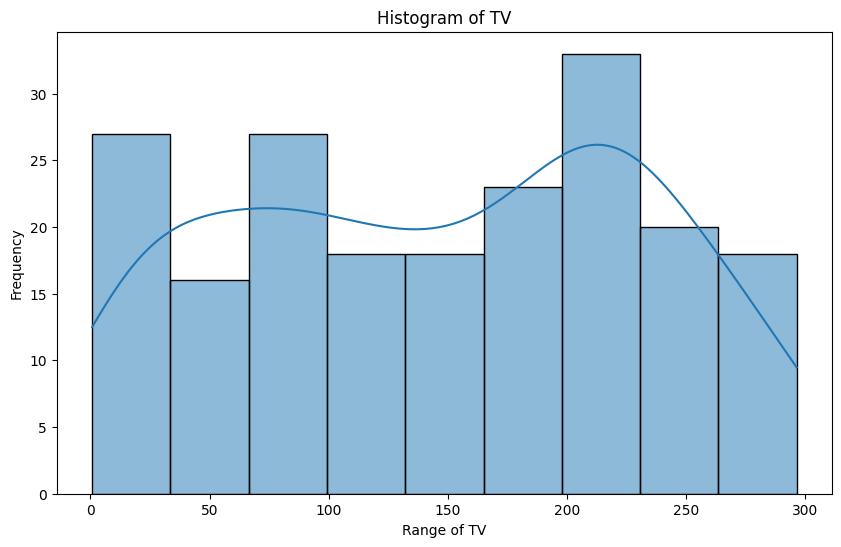

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TV'], kde=True)
plt.title('Histogram of TV')
plt.xlabel('Range of TV')
plt.ylabel('Frequency')
plt.show()

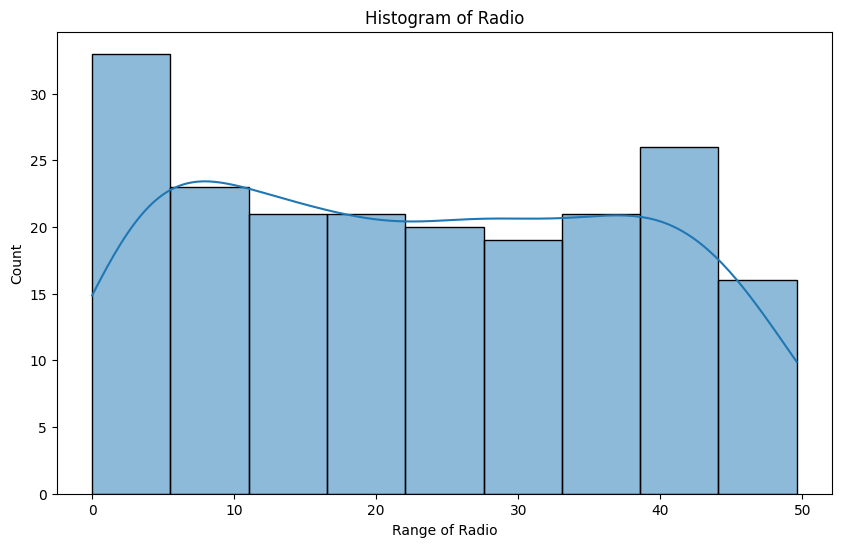

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Radio'], kde=True)
plt.title('Histogram of Radio')
plt.xlabel('Range of Radio')
plt.show()

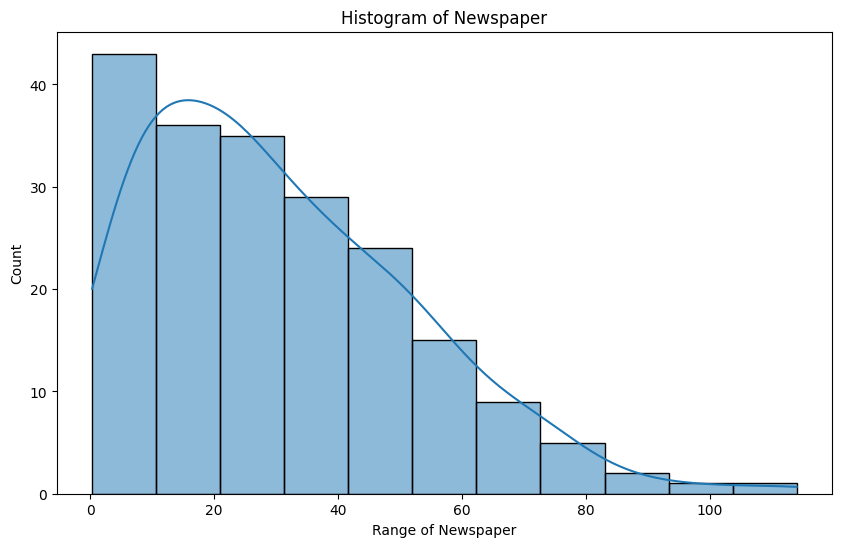

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Newspaper'], kde=True)
plt.title('Histogram of Newspaper')
plt.xlabel('Range of Newspaper')
plt.show()

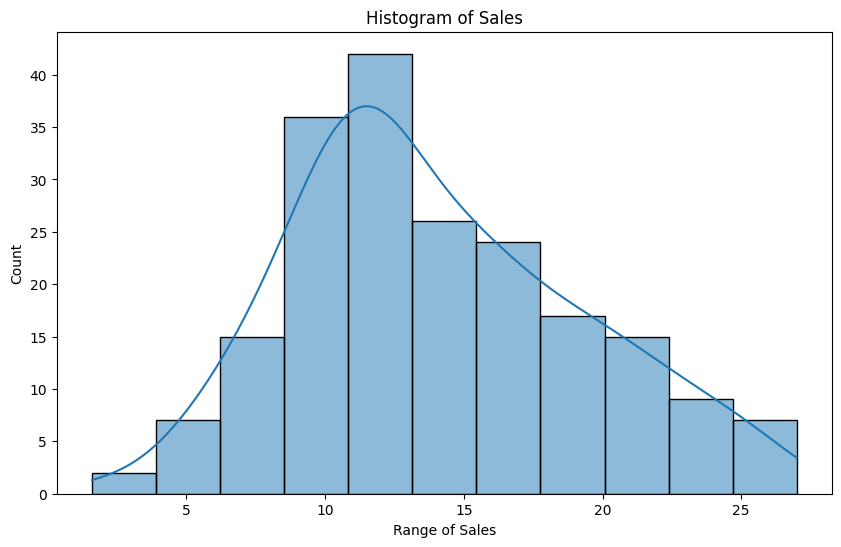

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True)
plt.title('Histogram of Sales')
plt.xlabel('Range of Sales')
plt.show()

<Axes: >

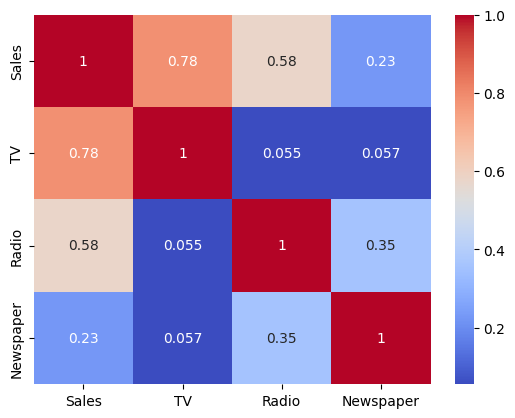

In [14]:
#heatmap
sns.heatmap(df_sales_wise.corr(), annot=True, cmap='coolwarm')

# machine learning

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score


In [16]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [18]:
#assigning independent and dependent values
x=df[['TV','Radio']].values
y=df['Sales'].values

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape

(160, 2)

In [21]:
model=LinearRegression()
model.fit(x_train, y_train)
y_pred=model.predict(x_test)

# error metrics

In [23]:
intercept=model.intercept_
slope=model.coef_
print(f"Intercept: {intercept}")
print(f"Slope: {slope}")


Intercept: 3.028255250783305
Slope: [0.0447283  0.19066726]


In [22]:
#calculating mae(mean absolute error)
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)
#calculating mse(mean squarred error)
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)
#calculating r2_score
r2=r2_score(y_test,y_pred)
print("R2 Score:",r2)

MAE: 1.4443023138227578
MSE: 3.137948009068353
R2 Score: 0.9005833101920356


# visualising models

In [27]:
print(x_test.shape)
print(y_test.shape)

(40, 2)
(40,)


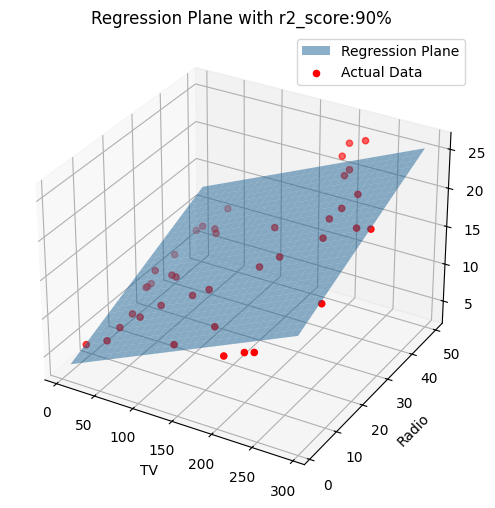

In [32]:
import matplotlib.pyplot as plt

# coefficients
intercept = 3.028255250783305
a1 = slope[0]
a2 = slope[1]

# Create grid
x1_range = np.linspace(x_test[:,0].min(), x_test[:,0].max(), 30)
x2_range = np.linspace(x_test[:,1].min(), x_test[:,1].max(), 30)

X1, X2 = np.meshgrid(x1_range, x2_range)

# Plane equation
Y = intercept + a1*X1 + a2*X2

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Regression plane
ax.plot_surface(X1, X2, Y, alpha=0.5,label='Regression Plane')

# Actual data points
ax.scatter(x_test[:,0], x_test[:,1], y_test,color='red',label='Actual Data')

ax.set_xlabel('TV')
ax.set_ylabel('Radio')
ax.set_zlabel('Sales')
plt.title('Regression Plane with r2_score:90%')
plt.legend()
plt.show()

In [34]:
#polynommial regression
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 5) # Transforming tool (degrees from 2 to 7 max to best fit curve)
x_poly = poly_reg.fit_transform(x)


In [ ]:
#splitting x_poly and y
x1_train, x1_test, y1_train, y1_test = train_test_split(x_poly, y, test_size=0.2, random_state=42)

In [49]:
model1 = LinearRegression()
model1.fit(x1_train, y1_train)
y1_pred = model1.predict(x1_test)

In [50]:
#print(y1_test.shape)
pd.DataFrame({'y_test':y_test,'y_pred':y_pred}).head()

,y_test,y_pred
0,16.9,16.357473
1,22.4,20.862994
2,21.4,21.525058
3,7.3,10.587198
4,24.7,22.224596


In [51]:
#calculating mae(mean absolute error)
mae=mean_absolute_error(y_test,y1_pred)
print("MAE:",mae)
#calculating mse(mean squarred error)
mse=mean_squared_error(y_test,y1_pred)
print("MSE:",mse)
#calculating r2_score
r2=r2_score(y_test,y1_pred)
print("R2 Score:",r2)

MAE: 0.3978357679423002
MSE: 0.24525702428778598
R2 Score: 0.9922297496847048


In [52]:
intercept=model1.intercept_
slope=model1.coef_

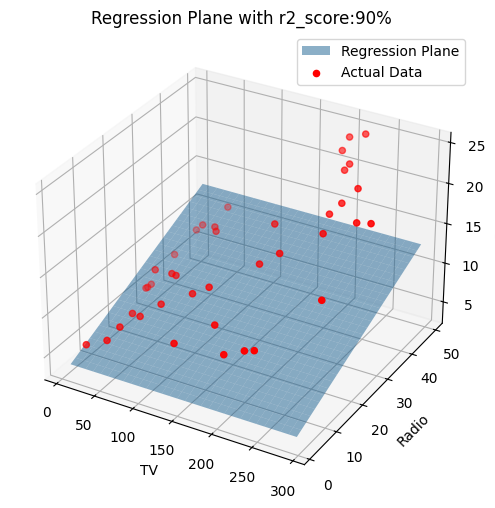

In [53]:
# coefficients
a1 = slope[0]
a2 = slope[1]

# Create grid
x1_range = np.linspace(x_test[:,0].min(), x_test[:,0].max(), 30)
x2_range = np.linspace(x_test[:,1].min(), x_test[:,1].max(), 30)

X1, X2 = np.meshgrid(x1_range, x2_range)

# Plane equation
Y = intercept + a1*X1 + a2*X2

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Regression plane
ax.plot_surface(X1, X2, Y, alpha=0.5,label='Regression Plane')

# Actual data points
ax.scatter(x_test[:,0], x_test[:,1], y_test,color='red',label='Actual Data')

ax.set_xlabel('TV')
ax.set_ylabel('Radio')
ax.set_zlabel('Sales')
plt.title('Regression Plane with r2_score:90%')
plt.legend()
plt.show()